In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("global_sports_footwear_sales_2018_2026.csv")

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [ ]:
# Check wheather any column as have null values??

df.isnull().sum()

,0
order_id,0
order_date,0
brand,0
model_name,0
category,0
gender,0
size,0
color,0
base_price_usd,0
discount_percent,0


In [ ]:
# Describe the data-set
df.describe()

,size,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,customer_rating
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,8.500867,139.634633,13.332167,121.029035,2.500200,302.714948,4.001543
std,1.710896,46.062549,9.864198,42.511586,1.121149,179.149272,0.577546
min,6.000000,60.000000,0.000000,42.000000,1.000000,42.000000,3.000000
25%,7.000000,100.000000,5.000000,85.000000,1.000000,156.750000,3.500000
50%,9.000000,140.000000,10.000000,119.200000,3.000000,268.200000,4.000000
75%,10.000000,180.000000,20.000000,153.600000,4.000000,414.000000,4.500000
max,11.000000,219.000000,30.000000,219.000000,4.000000,876.000000,5.000000


In [ ]:
# How many orders their in this data-set?
df['order_id'].count()

np.int64(30000)

In [3]:
# How many years of data are included in this dataset?
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year

In [ ]:
years = df['order_year'].unique()

for i in years:
  print(i)

print()

2021
2026
2023
2019
2020
2022
2025
2024
2018



2018 to 2026 Data are included

 **1. Categorical Data Analysis**

In [ ]:
# What are the types of brand ?

for i in (df['brand'].unique()):
  print(i)

ASICS
Reebok
Nike
New Balance
Adidas
Puma



There are mainly 6 types of footwear brands.

In [ ]:
# How many models does each brand have?

modelcount = df.groupby('brand')['model_name'].nunique().sort_values(ascending=False)
modelcount

,model_name
brand,
Adidas,897
New Balance,897
Nike,896
Reebok,894
ASICS,893
Puma,892


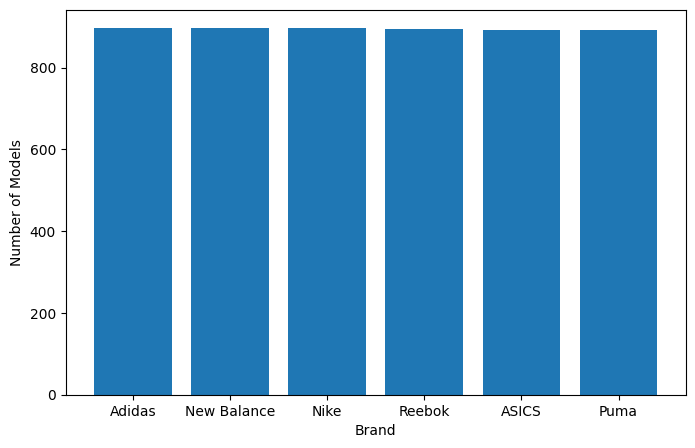

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(modelcount.index, modelcount.values)
plt.xlabel('Brand')
plt.ylabel('Number of Models')
plt.show()


As we can see, all brands have **nearly 900 models**; no brand has fewer than 800, and there isn't much difference between them.

In [ ]:
# What are the types of category does have each brands?

category_count = df.groupby('brand')['category'].nunique()
category_count


,category
brand,
ASICS,5
Adidas,5
New Balance,5
Nike,5
Puma,5
Reebok,5


As we can see all brands has have same number of category

In [ ]:
# What are the types of colour foorwear does have each brands?

colors = df.groupby('brand')['color'].nunique().sort_values(ascending=False)
colors

,color
brand,
ASICS,5
Adidas,5
New Balance,5
Nike,5
Puma,5
Reebok,5


Here also all the brands as have same number of colors.

**2. Bivariate Analysis.**

In [ ]:
# What are the different gender categories?

gender = df['gender'].unique()
gender

array(['Unisex', 'Men', 'Women'], dtype=object)

**Unisex** : Desinged for both male and female

**Male** : Designed for only male

**Female** : Designed for only female

In [ ]:
# How many orders were placed by each gender?

count_order_by_gender = df.groupby('gender')['order_id'].count()
count_order_by_gender

,order_id
gender,
Men,10075
Unisex,9868
Women,10057


As we can see, male and female customers have the same number of orders (10000). Unisex orders are also similar to the male and female counts, with each category being near 10,000. I think there are no significant differences between them.

In [ ]:
# Which brand is most ordered by males?

male_brand_cnt = df[df['gender'] == 'Men'].groupby('brand')['order_id'].count().sort_values(ascending=False)
male_brand_cnt

,order_id
brand,
New Balance,1723
Reebok,1708
ASICS,1692
Nike,1662
Adidas,1654
Puma,1636


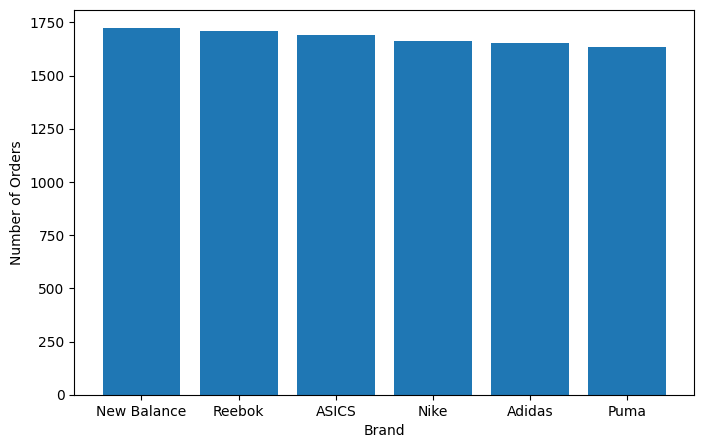

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(male_brand_cnt.index,male_brand_cnt.values)
plt.xlabel('Brand')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
# Which Brand is most ordered by Womens?

female_brand_cnt = df[df['gender'] =='Women'].groupby('brand')['order_id'].count().sort_values(ascending=False)
female_brand_cnt

,order_id
brand,
ASICS,1780
Adidas,1687
Puma,1677
Nike,1665
New Balance,1650
Reebok,1598


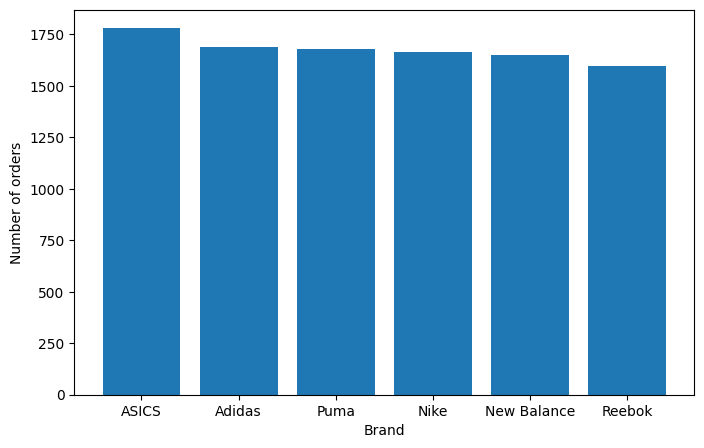

In [ ]:
# useing bar plot to show.

plt.figure(figsize=(8,5))
plt.bar(female_brand_cnt.index,female_brand_cnt.values)
plt.xlabel('Brand')
plt.ylabel('Number of orders')
plt.show()

In [ ]:
# Which brand is most ordered by unisex (either women/men)

unisex_brand_cnt = df[df['gender'] == 'Unisex'].groupby('brand')['order_id'].count().sort_values(ascending=False)
unisex_brand_cnt

,order_id
brand,
Reebok,1720
Nike,1691
ASICS,1660
Puma,1611
New Balance,1609
Adidas,1577


In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,order_year
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6,2021
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9,2026
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0,2023
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4,2026
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0,2019


In [ ]:
# Which footwear color is most ordered by men?
men_color = df[df['gender']=='Men'].groupby('color')['order_id'].count().sort_values(ascending=False)

men_color

,order_id
color,
Red,2048
Black,2032
White,2017
Blue,1997
Grey,1981


In [ ]:
# What is the most ordered footwear size for men?

men_size = df[df['gender']=='Men'].groupby('size')['order_id'].count().sort_values(ascending=False)

men_size

,order_id
size,
10,1720
7,1704
9,1685
11,1670
6,1665
8,1631


Here we can see the most ordered footwear size is 10 and also followed by footwear size 7.

There is no significant difference.

In [ ]:
# What is the average rating for each brand among men?

men_rating_avg = df[df['gender'] == 'Men'].groupby('brand')['customer_rating'].mean().sort_values(ascending=False)
men_rating_avg


,customer_rating
brand,
New Balance,4.019385
Puma,4.014303
ASICS,4.002069
Reebok,3.989520
Nike,3.988568
Adidas,3.967231



Men have given ratings of 4.0 to **New Balance, Puma, and ASICS**. Additionally, **Reebok, Nike, and Adidas** have ratings very close to 4.0.

In [ ]:
# What is the overall ratings by Men?

overall = df[df['gender'] =='Men']['customer_rating'].mean()
overall

np.float64(3.9969429280397026)

We can see overall rating is around 4 ratings i think all produts and brands are giving best quality and price.

In [ ]:
# What is the most common payment method used by men?

men_payment = df[df['gender'] == 'Men'].groupby('payment_method')['order_id'].count().sort_values(ascending=False)
men_payment

,order_id
payment_method,
Card,2536
Wallet,2535
Bank Transfer,2504
Cash,2500


There is no significant differnce all type payment method is used by Men.

In [ ]:
# Which footwear color is most ordered by Women?

woment_order = df[df['gender'] == 'Women'].groupby('color')['order_id'].count().sort_values(ascending=False)
woment_order

,order_id
color,
Grey,2054
Red,2045
Blue,2022
White,1981
Black,1955


In [ ]:
# What is the most ordered footwear size for Women?

women_size = df[df['gender'] == 'Women'].groupby('size')['order_id'].count().sort_values(ascending=False)

women_size

,order_id
size,
9,1701
11,1694
7,1684
6,1673
8,1663
10,1642


In [ ]:
# What is the average rating for each brand among Women?

women_ratings = df[df['gender'] == 'Women'].groupby('brand')['customer_rating'].mean().sort_values(ascending=False)
women_ratings

,customer_rating
brand,
Reebok,4.024468
Adidas,4.009306
ASICS,4.008764
Nike,4.006667
Puma,4.003160
New Balance,3.988970


Here we can see all brands have good average ratings

In [ ]:
# What is the overall ratings by Women?

overall_rating_by_women = df[df['gender']=='Women']['customer_rating'].mean()

overall_rating_by_women

np.float64(4.006821119618177)

Overall ratings is 4

In [ ]:
# What is the most common payment method used by Women?

payment_method_by_women = df[df['gender'] == 'Women'].groupby('payment_method')['order_id'].count()

payment_method_by_women

,order_id
payment_method,
Bank Transfer,2630
Card,2448
Cash,2444
Wallet,2535


As we can see, Bank Transfer is the most used method by women, while Cards are most used by men.

In [ ]:
# What is the count of each income level category?

df['customer_income_level'].value_counts()

,count
customer_income_level,
High,10059
Medium,9997
Low,9944


As we can see, all customer types have ordered footwear and also there is no more count differnces.

In [ ]:
# What is the count of each income level category for women?

women_inc_lvl = df[df['gender'] =='Women'].groupby('customer_income_level')['order_id'].count().sort_values(ascending=False)
women_inc_lvl

,order_id
customer_income_level,
High,3371
Low,3347
Medium,3339


In [ ]:
# What is the count of each income level category for men?

men_inc_lvl = df[df['gender'] == 'Men'].groupby('customer_income_level')['order_id'].count().sort_values(ascending=False)
men_inc_lvl

,order_id
customer_income_level,
Medium,3383
High,3363
Low,3329


Both **men** and **women** across all income categories have ordered products; there is no significant difference between the high, medium, and low levels.

**3.Revenue Analysis**


In [ ]:
# What is total revenue generted by each brands?

total_brand_rev = df.groupby('brand')['revenue_usd'].sum().sort_values(ascending=False)


# total brand revenue in crore?

# 1 usd = 90.89

grand = 0
for key,val in total_brand_rev.items():
  grand += val * 90.89
  print(f'\n {key}: {round(val * 90.89)}Cr, USD:{val}')

print(f'\n The Total Revenue is: {round(grand)}Cr, USD:{total_brand_rev.sum()}')


 ASICS: 141921327Cr, USD:1561462.5

 Nike: 138569267Cr, USD:1524582.1

 New Balance: 137371282Cr, USD:1511401.5

 Puma: 136252735Cr, USD:1499094.9

 Reebok: 136211471Cr, USD:1498640.9

 Adidas: 135086767Cr, USD:1486266.55

 The Total Revenue is: 825412850Cr, USD:9081448.450000001


**ASICS** is the top-selling brand, reaching **14 crore**, followed by **Nike**, **New Balance ,Puma**, **Reebok**, and **Adidas**, which are all in the 13 crore range.

In [ ]:
# Which category type generated the highest revenue?

cat_rev = df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)

cat_rev


,revenue_usd
category,
Lifestyle,1844628.75
Training,1836338.65
Basketball,1822369.65
Running,1805450.70
Gym,1772660.70


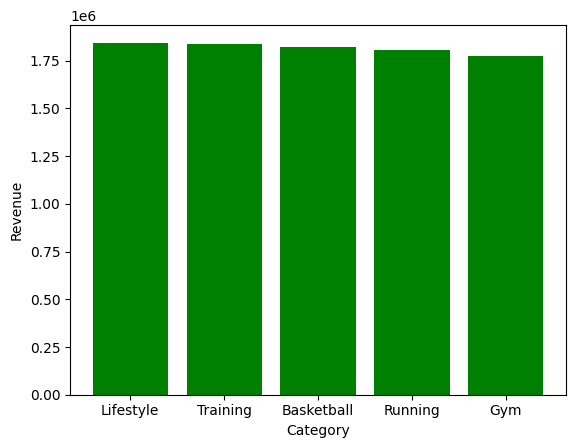

In [ ]:
# plot

plt.bar(cat_rev.index,cat_rev.values,color='green')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

In [ ]:
category_rev = df.groupby(['brand','category'])['revenue_usd'].sum()

category_rev = category_rev.reset_index() # make as it is column names back

s = category_rev.sort_values(by=['brand','category','revenue_usd'],ascending=[False,False,True])

s

,brand,category,revenue_usd
29,Reebok,Training,298151.05
28,Reebok,Running,309787.15
27,Reebok,Lifestyle,298063.00
26,Reebok,Gym,297825.60
25,Reebok,Basketball,294814.10
24,Puma,Training,288147.20
23,Puma,Running,295246.95
22,Puma,Lifestyle,318943.60
21,Puma,Gym,292576.05
20,Puma,Basketball,304181.10


In [ ]:
# What is the number of orders for each brand?

brand_order = df.groupby('brand')['order_id'].count().sort_values(ascending=False)
brand_order

,order_id
brand,
ASICS,5132
Reebok,5026
Nike,5018
New Balance,4982
Puma,4924
Adidas,4918


In [ ]:
# Which color is made highest revenue?

overall_color = df.groupby('color')['revenue_usd'].sum().sort_values(ascending=False)
overall_color

,revenue_usd
color,
Grey,1837362.15
Red,1829753.35
Blue,1823077.55
White,1801333.50
Black,1789921.90


**Grey** color is made the highest revenue

In [ ]:
# Which size footwear as made highest revenue

overall_size = df.groupby('size')['revenue_usd'].sum().sort_values(ascending=False)
overall_size


,revenue_usd
size,
7,1530301.30
11,1519711.10
9,1518952.30
6,1508408.30
10,1503790.10
8,1500285.35


In [ ]:
# Which size footwear as made highest revenue in each brands?

brand_size = df.groupby(['brand','size'])['revenue_usd'].sum().sort_values(ascending=False)
brand_size

brand        size
ASICS        8       266442.85
             10      264797.15
Nike         7       263849.55
ASICS        9       262307.35
Reebok       11      261401.65
ASICS        6       260272.45
Nike         6       259511.70
Adidas       7       259078.10
New Balance  7       258855.50
Reebok       9       258230.75
New Balance  10      257538.05
Nike         8       256872.60
Puma         11      255556.70
ASICS        11      254147.35
Puma         9       254038.00
Nike         9       253650.85
ASICS        7       253495.35
Adidas       6       253458.80
             11      253354.55
New Balance  6       253268.00
Puma         7       253050.25
             10      253029.95
Reebok       8       249716.75
New Balance  9       249517.40
Nike         11      248155.45
New Balance  11      247095.40
Puma         8       246933.30
Reebok       6       245410.65
New Balance  8       245127.15
Adidas       10      243974.45
Nike         10      242541.95
Reebok       7       241972.55
             10      241908.55
Adidas       9       241207.95
Puma         6       236486.70
Adidas       8       235192.70
Name: revenue_usd, dtype: float64

In [ ]:
# What is the revenue by each sales channel?

sales_channel = df.groupby('sales_channel')['revenue_usd'].sum().sort_values(ascending=False)
sales_channel

,revenue_usd
sales_channel,
Retail Store,4540819.25
Online,4540629.20


Both **Retail Store, Online** channels made good revenue there is no significante diffrence


In [ ]:
# What is the total revenue generated by each payment method?

payment_method = df.groupby('payment_method')['revenue_usd'].sum().sort_values(ascending=False)
payment_method

,revenue_usd
payment_method,
Bank Transfer,2346208.60
Wallet,2271555.05
Card,2249505.65
Cash,2214179.15


**UPI** is the most used payment method by customers, followed by **wallets**, **cards, and cash.**

In [ ]:
# Which footwear brand has the highest unit sales?

brand_unit = df.groupby('brand')['units_sold'].sum().sort_values(ascending=False)
brand_unit



,units_sold
brand,
ASICS,12874
New Balance,12541
Nike,12481
Reebok,12469
Adidas,12326
Puma,12315


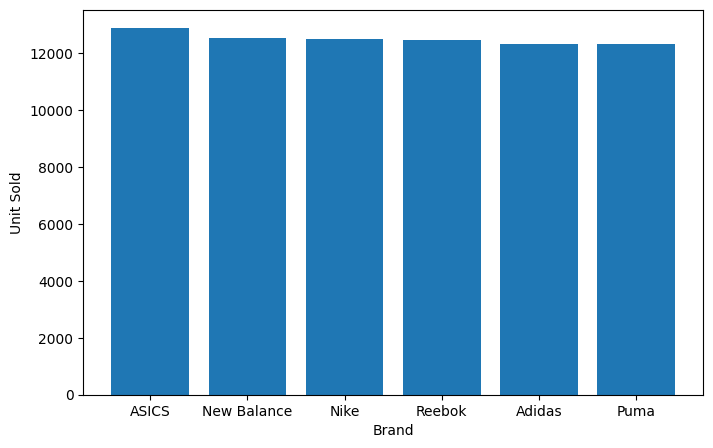

In [ ]:
#plot

plt.figure(figsize=(8,5))
plt.bar(brand_unit.index,brand_unit.values)
plt.xlabel('Brand')
plt.ylabel('Unit Sold')
plt.show()
#

In [ ]:
# Which gender generated the highest revenue?

gender_rev = df.groupby('gender')['final_price_usd'].sum().sort_values(ascending=False)
gender_rev
#

,final_price_usd
gender,
Women,1218177.75
Men,1216590.60
Unisex,1196102.70



**Women** generated the highest revenue, followed by men, with the kids' segment usually holding the third position.

In [ ]:
# Which income level category generated highest revenue?

cat_rev = df.groupby('customer_income_level')['revenue_usd'].sum().sort_values(ascending=False)
cat_rev

,revenue_usd
customer_income_level,
Low,3040581.20
High,3037804.30
Medium,3003062.95


Here we can see all the category levels are ordering the products.

In [ ]:
# What is the average discount given by all the brands?

avg_discount = df.groupby('brand')['discount_percent'].mean()
avg_discount

,discount_percent
brand,
ASICS,13.302806
Adidas,13.479057
New Balance,13.269771
Nike,13.190514
Puma,13.539805
Reebok,13.218265


Across the board, all brands offer an average discount between **13% and 14%** on their products.

**4.Retail Trend Analysis**

In [ ]:
# Which year had the highest order count?

year_order = df.groupby('order_year')['order_id'].count().sort_values(ascending=False)
year_order


,order_id
order_year,
2022,3441
2019,3387
2020,3379
2023,3363
2025,3351
2026,3309
2018,3291
2021,3275
2024,3204


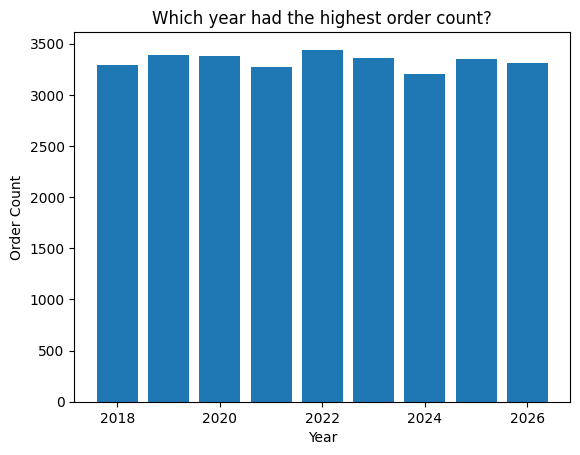

In [ ]:
plt.bar(year_order.index,year_order.values)
plt.title('Which year had the highest order count?')
plt.xlabel('Year')
plt.ylabel('Order Count')
plt.show()

In [4]:
# Which month had highet Revenue from each year?

# there is no month table ,for this we need to extract month

df['month'] = df['order_date'].dt.month

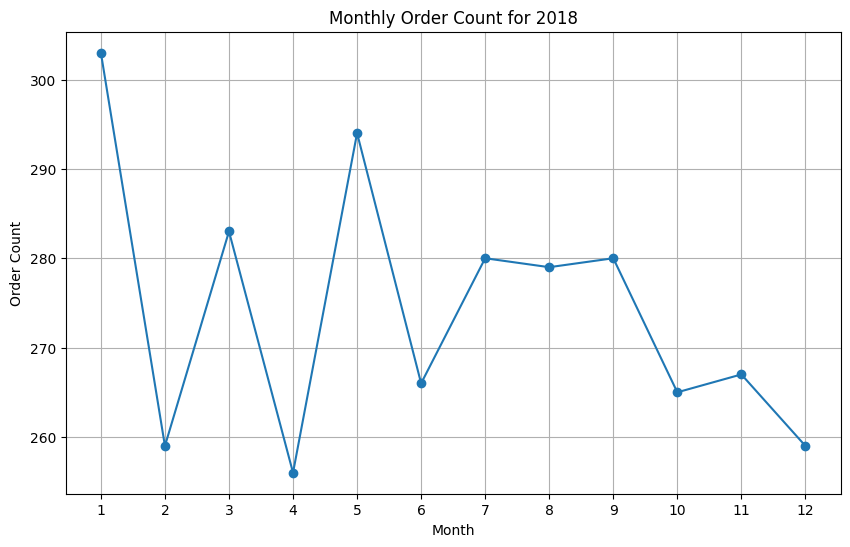

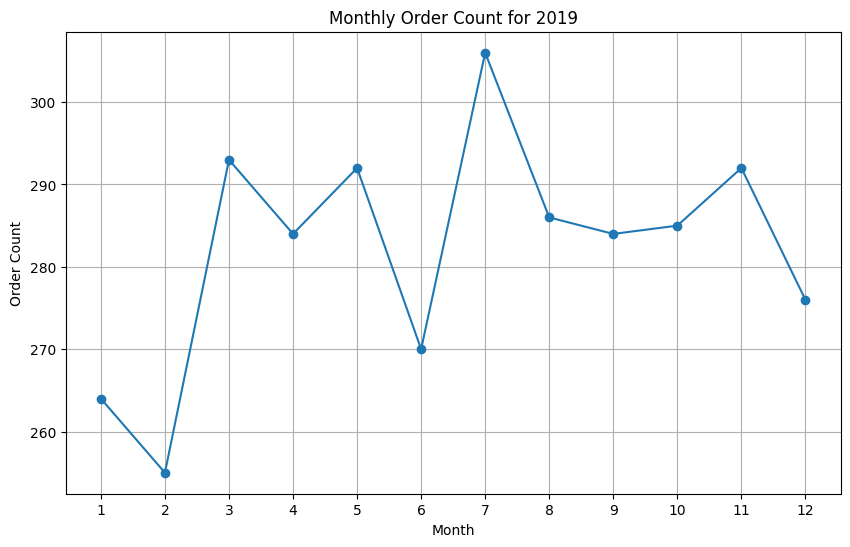

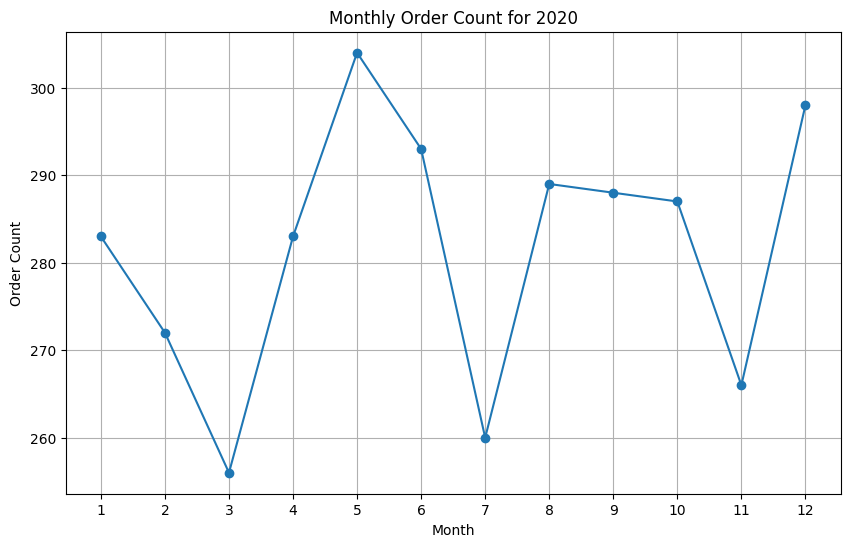

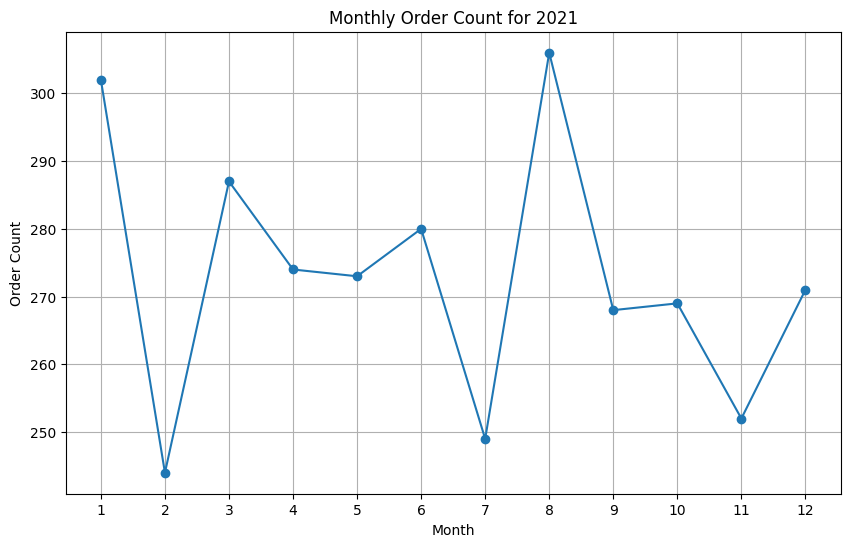

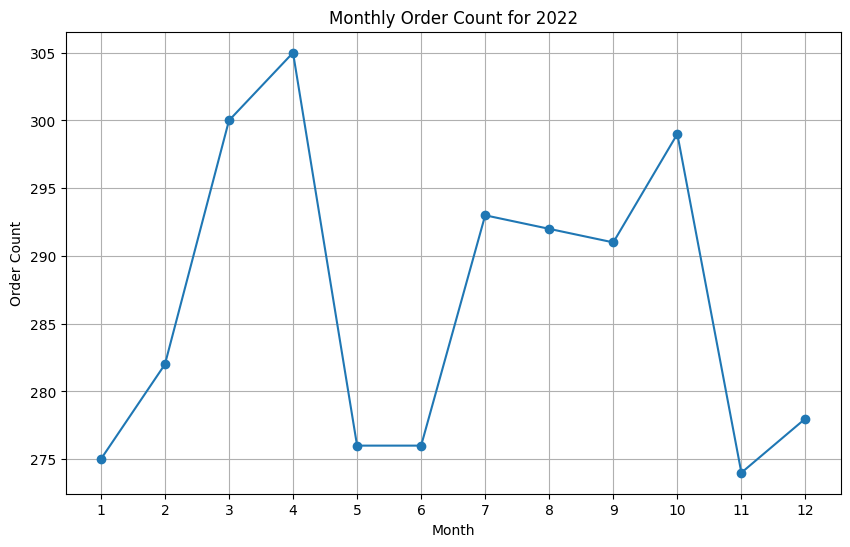

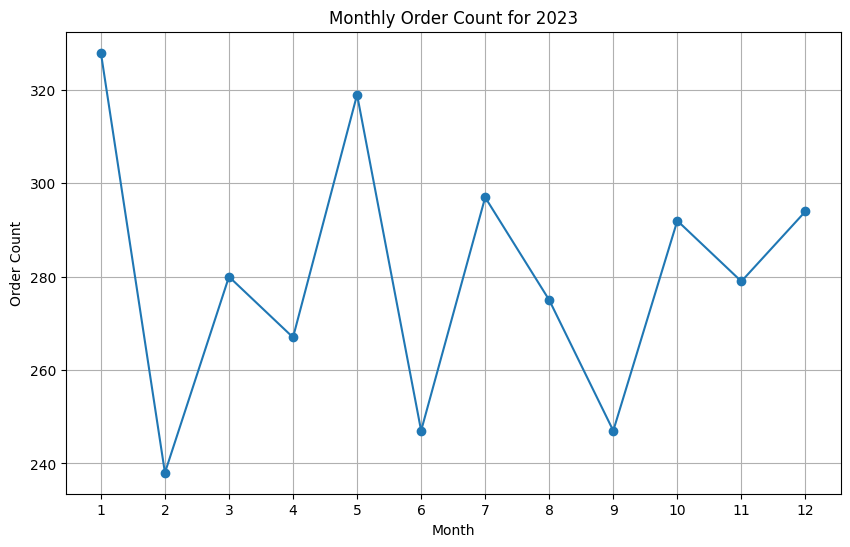

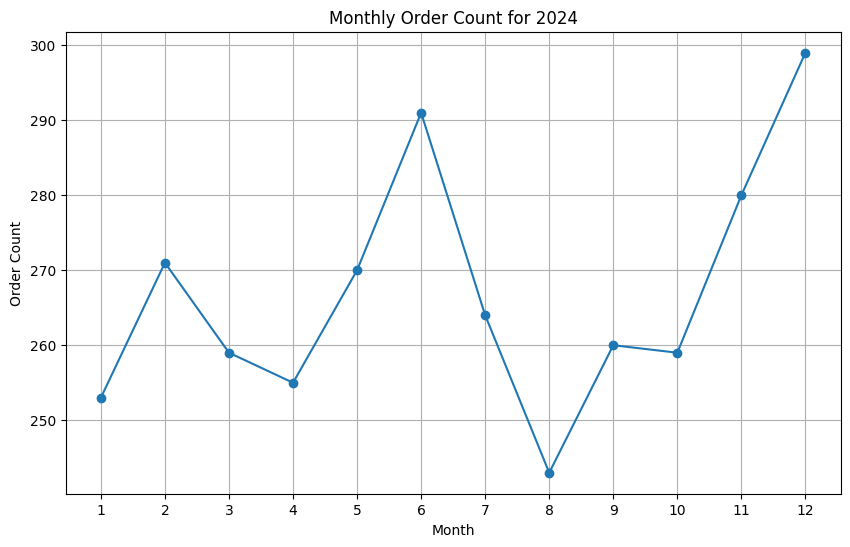

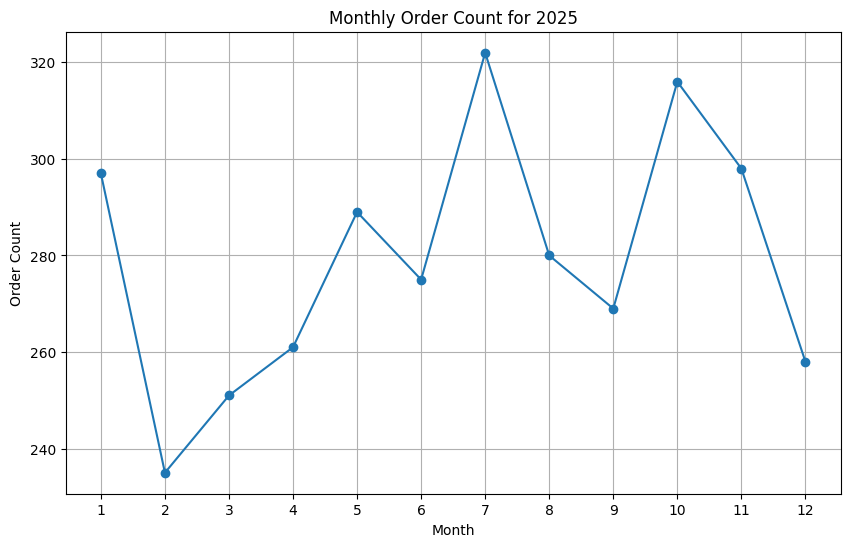

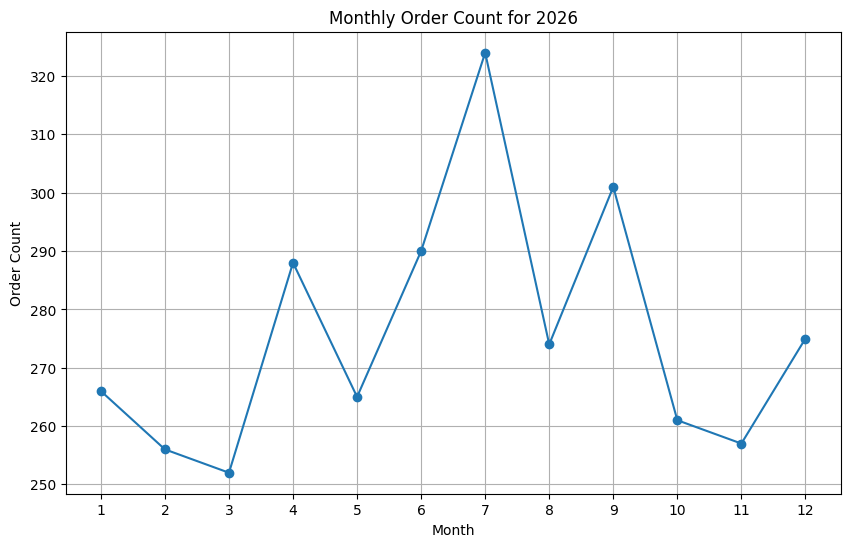

In [ ]:
import matplotlib.pyplot as plt

years = df['order_year'].unique()

for year in sorted(years):
    month_data = df[df['order_year'] == year].groupby('month')['order_id'].count()
    plt.figure(figsize=(10, 6))
    plt.plot(month_data.index, month_data.values, marker='o')
    plt.title(f'Monthly Order Count for {year}')
    plt.xlabel('Month')
    plt.ylabel('Order Count')
    plt.xticks(range(1, 13))
    plt.grid(True)
    plt.show()

In [ ]:
# Which Month had made highest order?

month_order = df.groupby('month')['order_id'].count().sort_values(ascending=False)
month_order

,order_id
month,
7,2595
5,2582
1,2571
10,2533
8,2524
12,2508
9,2488
6,2488
4,2473


In [ ]:
# Which Month had made highest revenue?

month_rev = df.groupby('month')['revenue_usd'].sum().sort_values(ascending=False)
month_rev
#

,revenue_usd
month,
10,785484.80
7,783344.95
5,778805.40
1,771040.40
12,764489.50
8,756421.05
4,752074.50
3,751808.65
9,750702.90


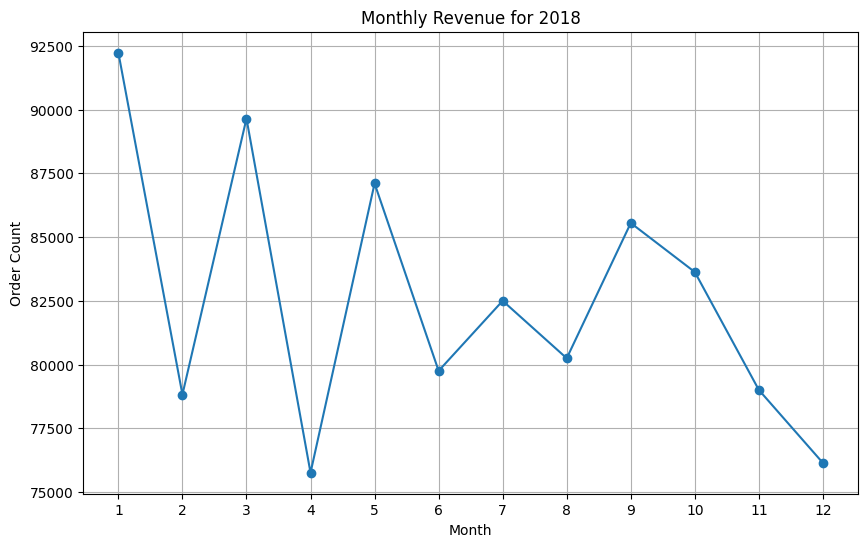

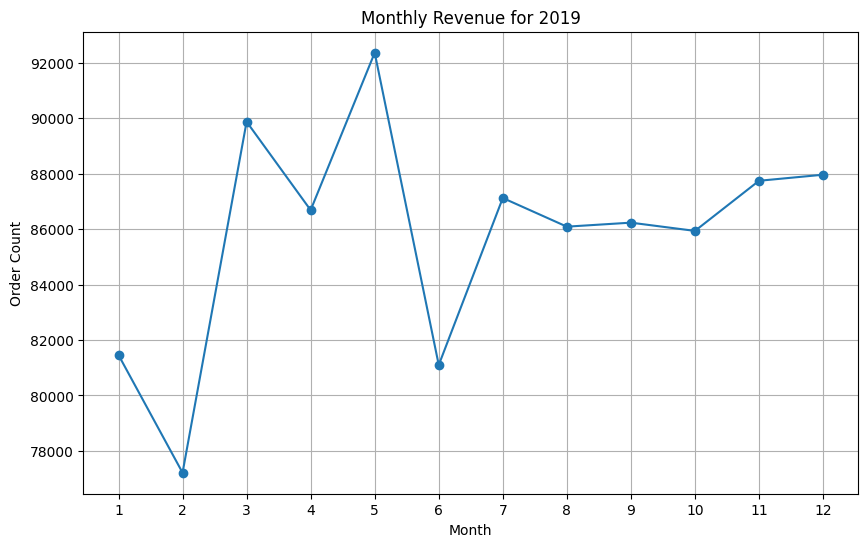

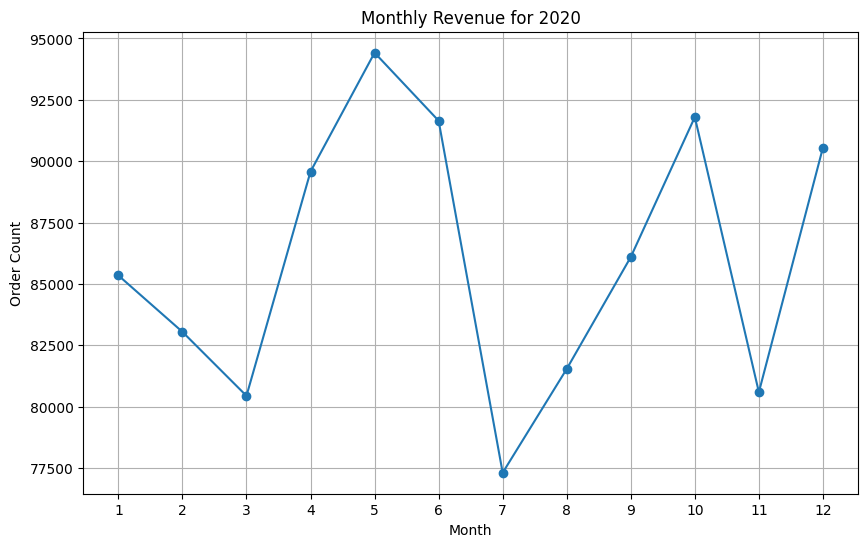

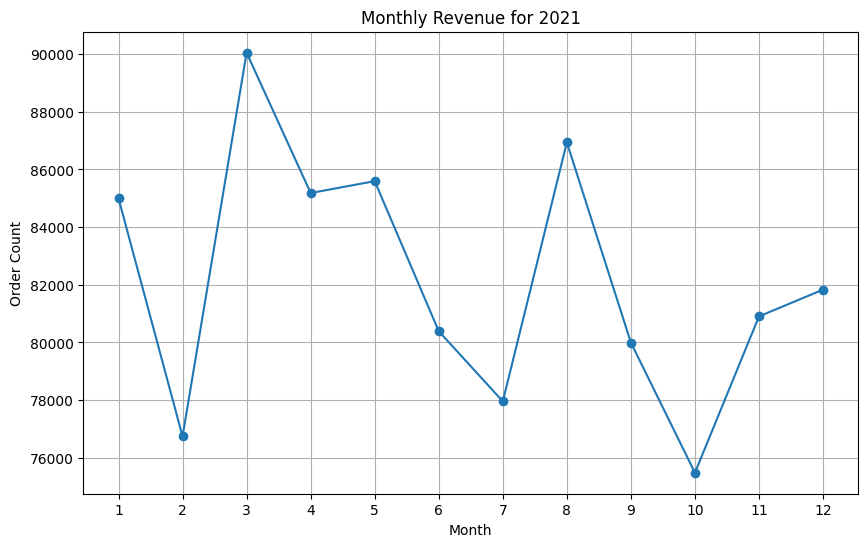

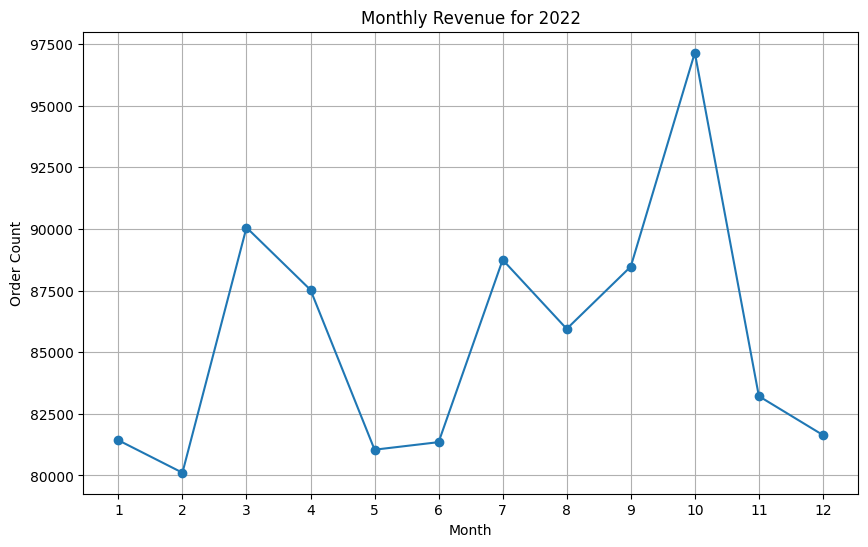

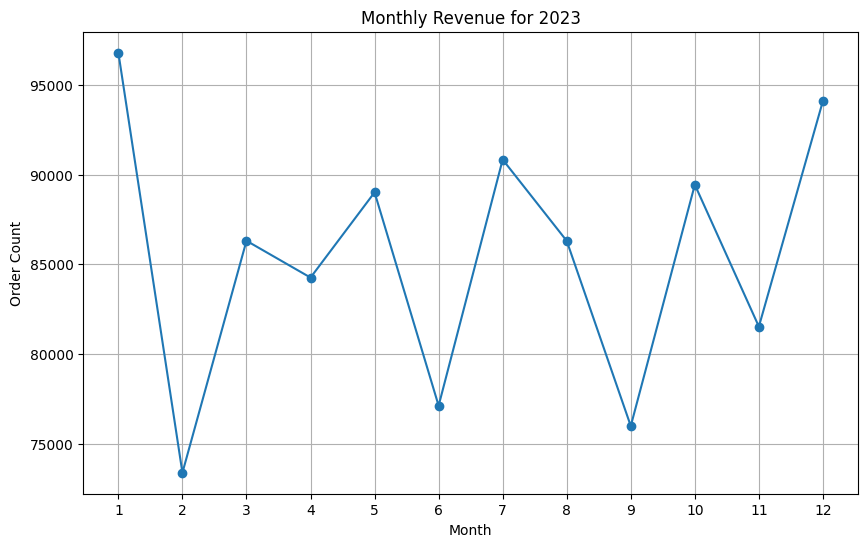

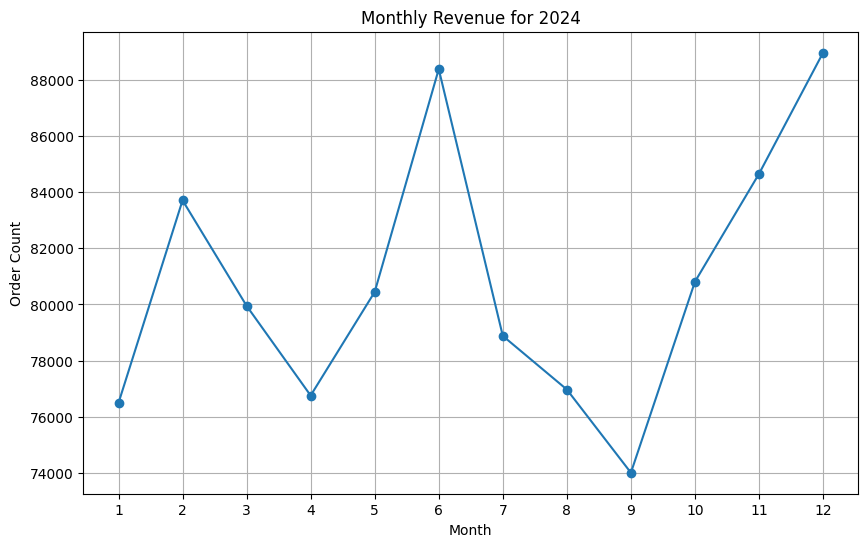

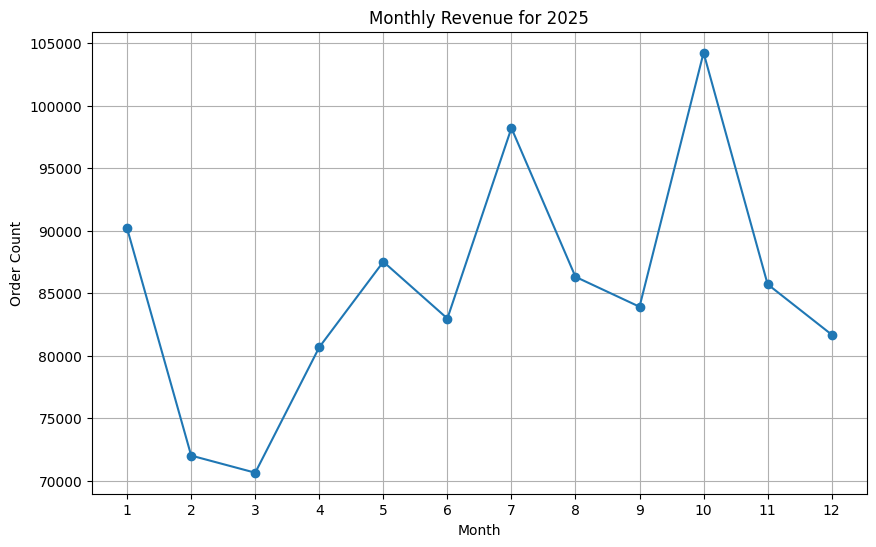

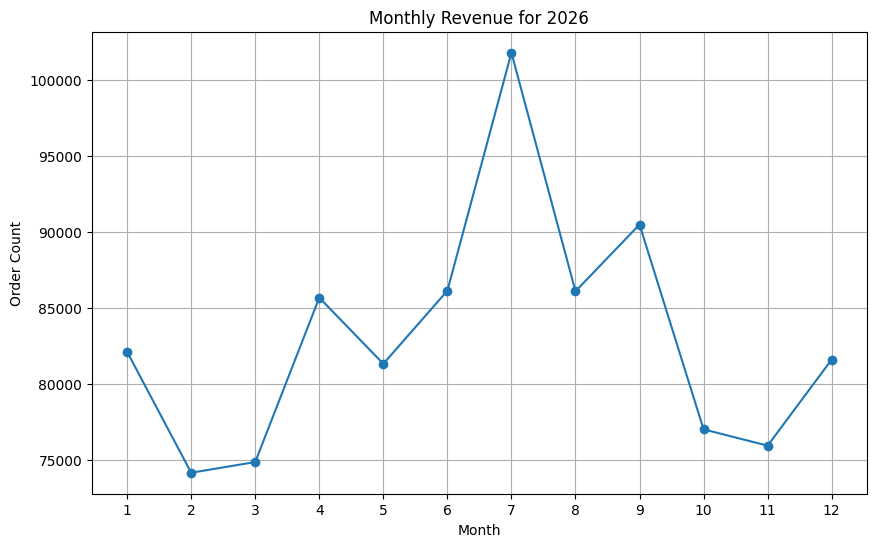

In [ ]:
# Which month had highet Revenue from each year?

years = df['order_year'].unique()

for year in sorted(years):
    month_data = df[df['order_year'] == year].groupby('month')['revenue_usd'].sum()
    plt.figure(figsize=(10, 6))
    plt.plot(month_data.index, month_data.values, marker='o')
    plt.title(f'Monthly Revenue for {year}')
    plt.xlabel('Month')
    plt.ylabel('Order Count')
    plt.xticks(range(1, 13))
    plt.grid(True)
    plt.show()






In [ ]:
# What is count of order where discount is low?

minn = df['discount_percent'].min()
df[df['discount_percent'] == minn]['order_id'].count()


np.int64(4971)

In [ ]:
# What is count of order where discount is high?

maxx = df['discount_percent'].max()
df[df['discount_percent'] == maxx]['order_id'].count()


np.int64(5003)

We can see that while customers order more when discounts are high, they also continue to purchase when discounts are low, showing they are not overly concerned with the discount level.

In [ ]:
# Which year made highest revenue? what is count of order?

year_rev = df.groupby('order_year')['revenue_usd'].sum().sort_values(ascending=False)
year_order = df.groupby('order_year')['order_id'].count().sort_values(ascending=False)

print(year_rev)
print(year_order)


order_year
2020    1032345.75
2019    1029728.15
2022    1026659.90
2023    1025135.90
2025    1024096.85
2026     996996.80
2018     990380.20
2021     986065.65
2024     970039.25
Name: revenue_usd, dtype: float64
order_year
2022    3441
2019    3387
2020    3379
2023    3363
2025    3351
2026    3309
2018    3291
2021    3275
2024    3204
Name: order_id, dtype: int64
30000


**5.Country-Region Analysis**

In [ ]:
# Which countries are included in this data?

df['country'].unique()
for i in df['country'].unique():
  print('\n',i)



 Germany

 USA

 India

 UK

 UAE

 Pakistan


In [ ]:
# Which country had made highest Revenue?

country_rev = df.groupby('country')['revenue_usd'].sum().sort_values(ascending=False)
country_rev

,revenue_usd
country,
UAE,1546442.55
UK,1532300.05
India,1520898.95
USA,1511747.45
Germany,1503894.85
Pakistan,1466164.60


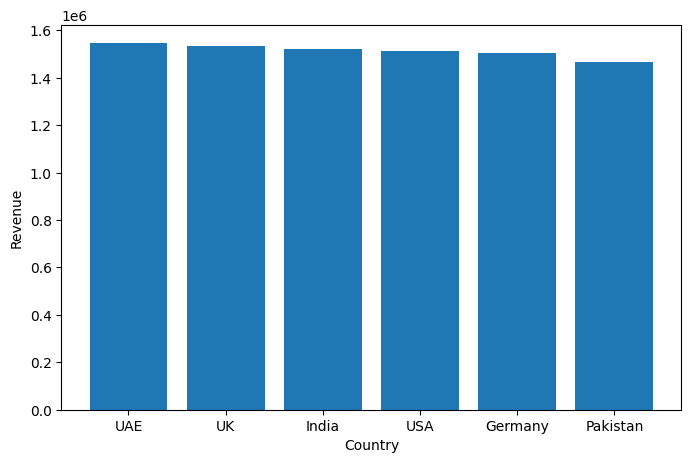

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(country_rev.index,country_rev.values)
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

In [ ]:
# Which country had highest number of orders?

country_order = df.groupby('country')['order_id'].count().sort_values(ascending=False)
country_order
#

,order_id
country,
UAE,5118
UK,5058
USA,5027
India,4991
Germany,4965
Pakistan,4841


All countries show the same rankings for total revenue and the number of orders.

In [ ]:
# What is average revenue by each country?

avg_rev_country = df.groupby('country')['revenue_usd'].mean().sort_values(ascending=False)
avg_rev_country

,revenue_usd
country,
India,304.728301
UK,302.945838
Germany,302.899265
Pakistan,302.863995
UAE,302.157591
USA,300.725572


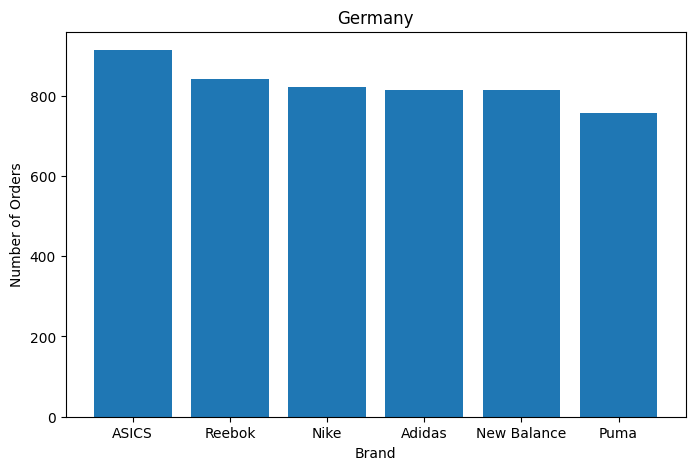

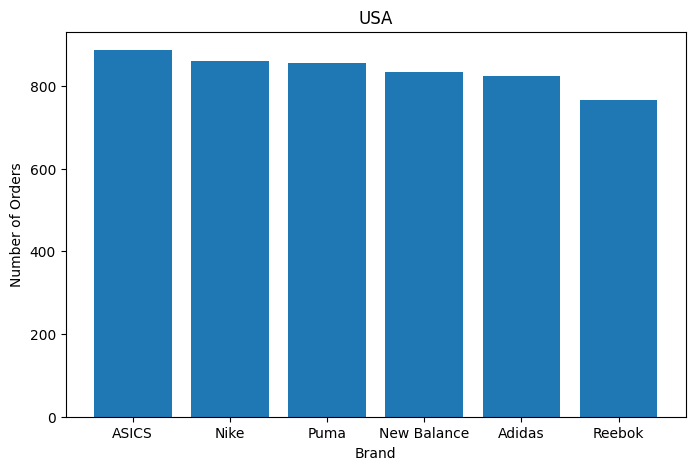

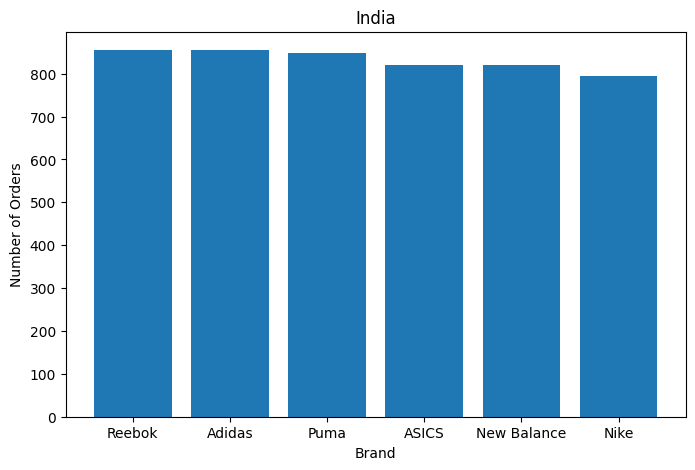

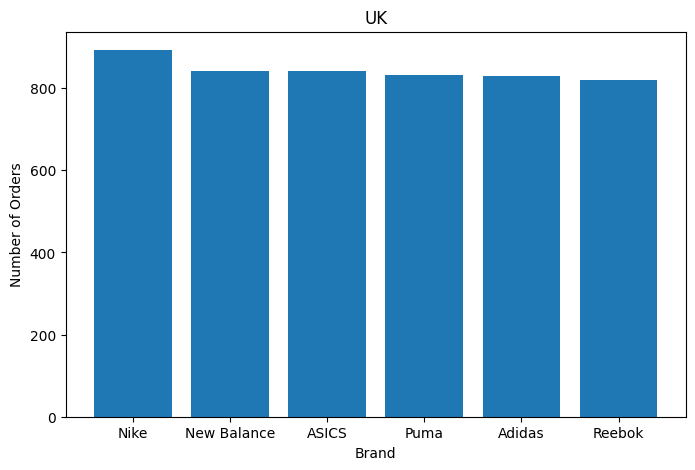

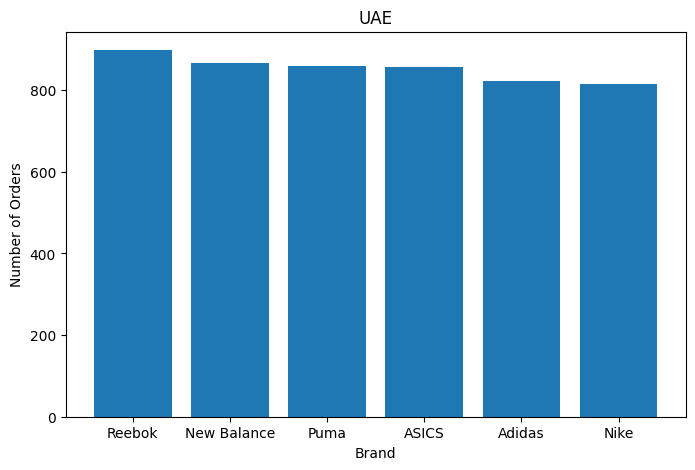

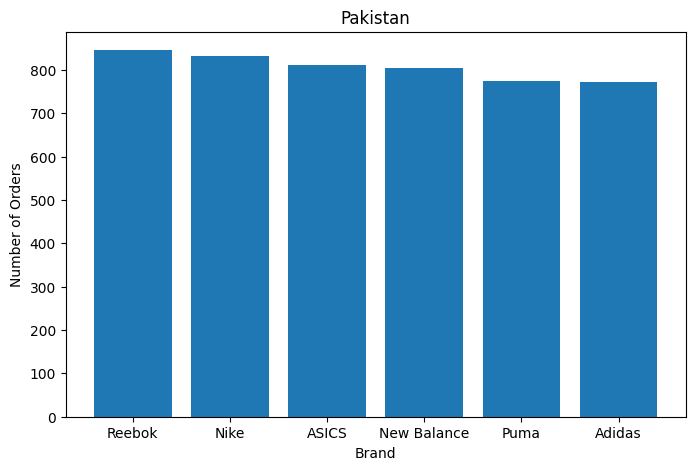

In [ ]:
# Which brand is most ordered by each country?

country = df['country'].unique()

for i in country:
  brand = df[df['country'] == i].groupby('brand')['order_id'].count().sort_values(ascending=False)
  plt.figure(figsize=(8,5))
  plt.bar(brand.index,brand.values)
  plt.xlabel('Brand')
  plt.ylabel('Number of Orders')
  plt.title(i)
  plt.show()


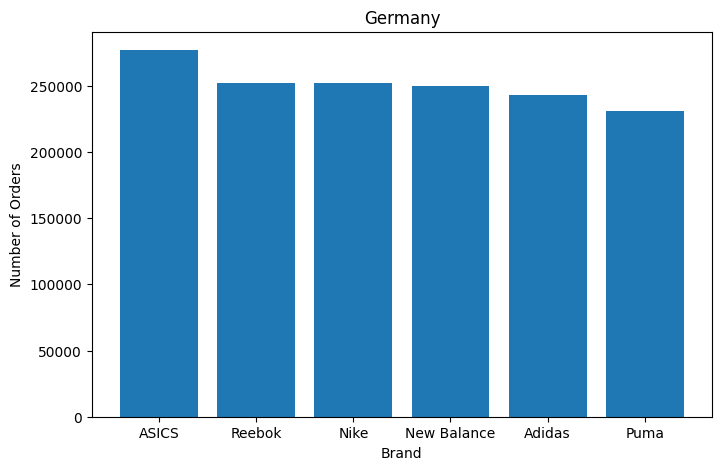

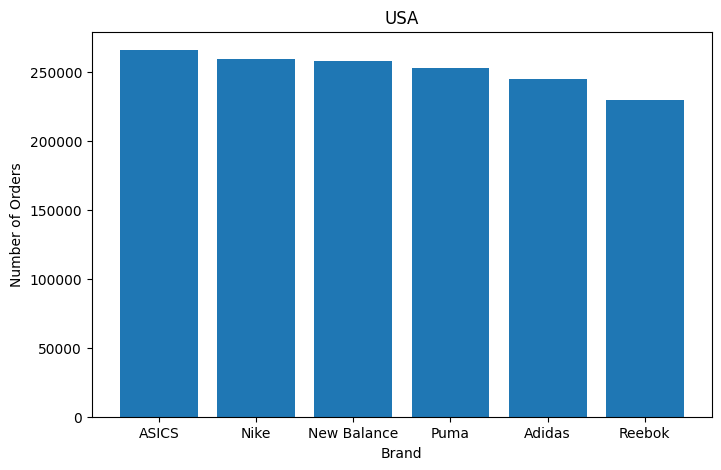

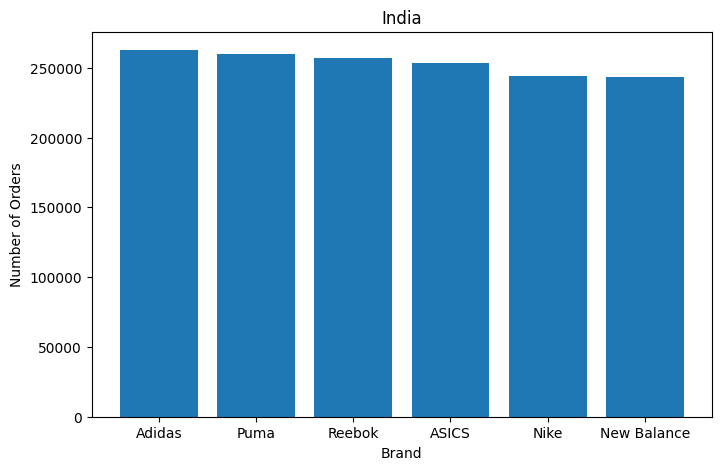

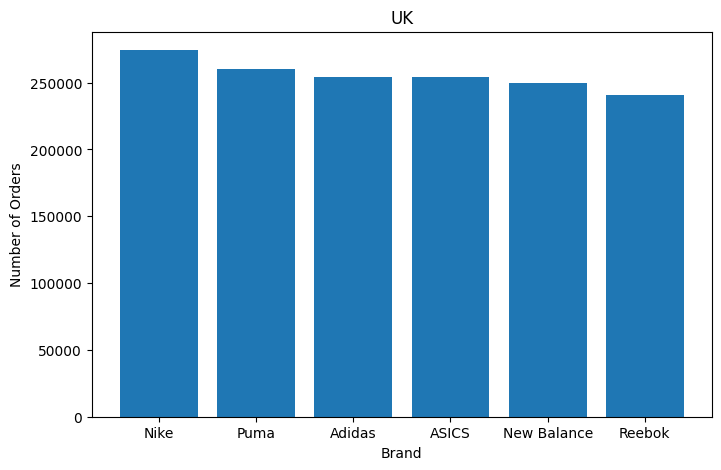

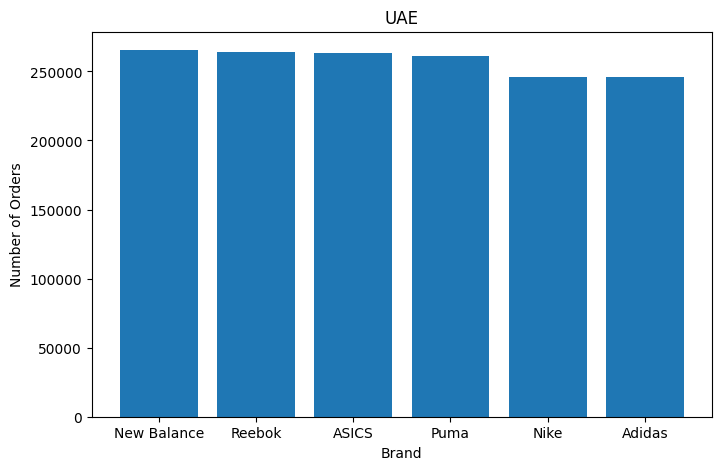

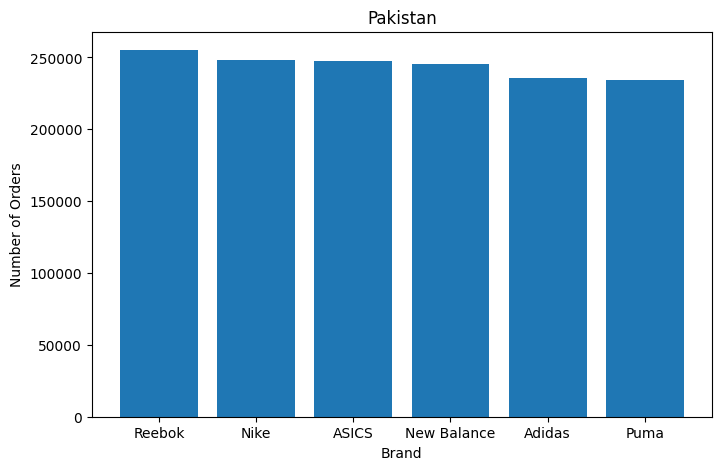

In [7]:
# which brand is generated highest revenue by each country?

country = df['country'].unique()

for i in country:
  brand = df[df['country'] == i].groupby('brand')['revenue_usd'].sum().sort_values(ascending=False)
  plt.figure(figsize=(8,5))
  plt.bar(brand.index,brand.values)
  plt.xlabel('Brand')
  plt.ylabel('Number of Orders')
  plt.title(i)
  plt.show()

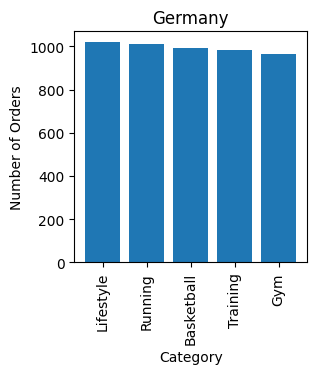

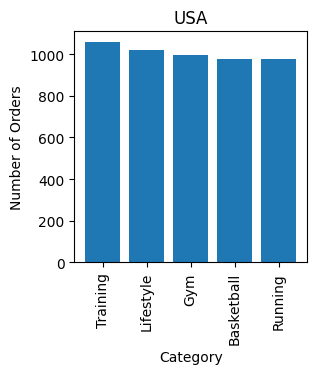

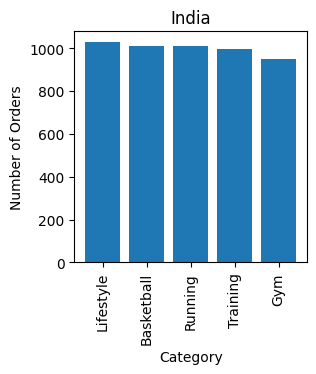

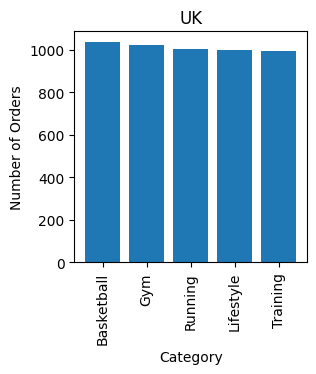

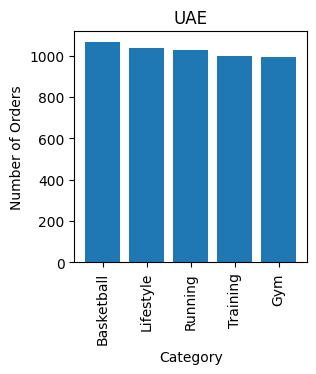

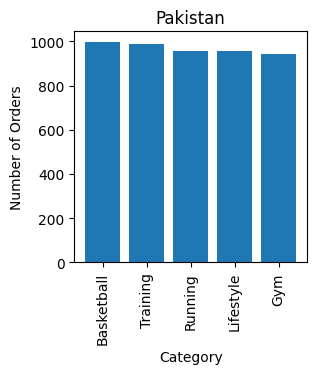

In [ ]:
# which category is most ordered by each country?

for i in country:
  category = df[df['country'] == i].groupby('category')['order_id'].count().sort_values(ascending=False)
  plt.figure(figsize=(3,3))
  plt.bar(category.index,category.values)
  plt.xticks(rotation=90)
  plt.xlabel('Category')
  plt.ylabel('Number of Orders')
  plt.title(i)
  plt.show()


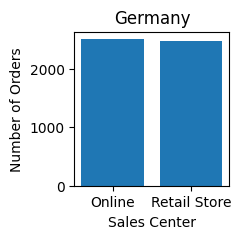

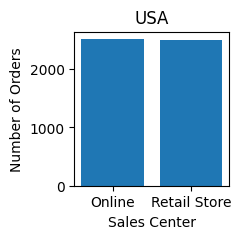

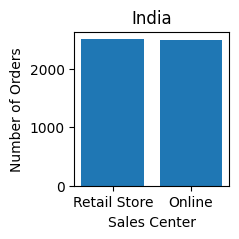

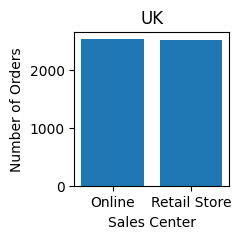

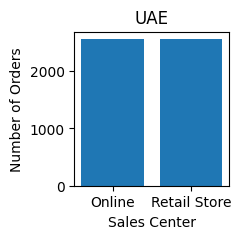

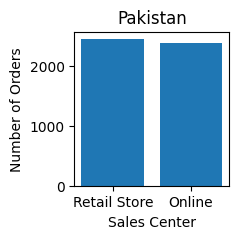

In [ ]:
from typing import AsyncGenerator
# Which Sales center most used by each country?

for i in country:
  sc = df[df['country'] == i].groupby('sales_channel')['order_id'].count().sort_values(ascending=False)
  plt.figure(figsize=(2,2))
  plt.bar(sc.index,sc.values)
  plt.title(i)
  plt.xlabel('Sales Center')
  plt.ylabel('Number of Orders')
  plt.show()




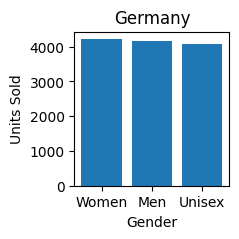

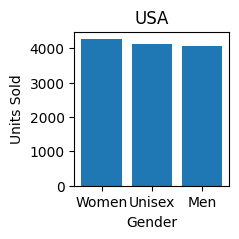

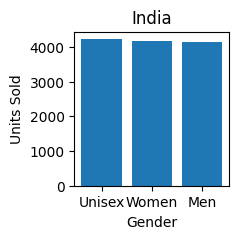

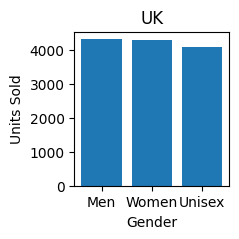

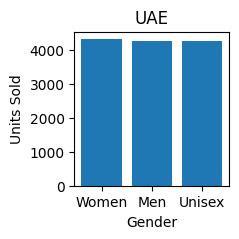

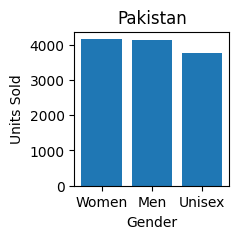

In [ ]:
# Which the number of unitsold gender by each country?


for i in country:
  unit_sold = df[df['country'] ==i].groupby('gender')['units_sold'].sum().sort_values(ascending=False)
  plt.figure(figsize=(2,2))
  plt.bar(unit_sold.index,unit_sold.values)
  plt.title(i)
  plt.xlabel('Gender')
  plt.ylabel('Units Sold')
  plt.show()
#


on colour?   
payment method?    
customer income level?    
cutomer rating on each brand?   


In [5]:
"""from google.colab import files
df.to_csv('global_footwear_cleaned_data.csv', index=False)
files.download('global_footwear_cleaned_data.csv')"""

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

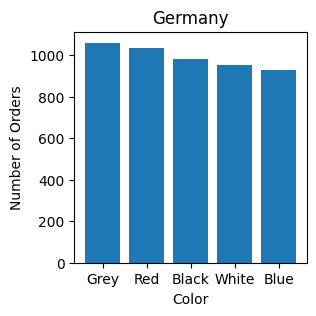

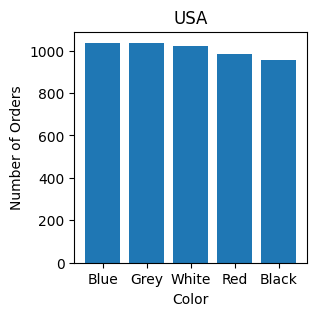

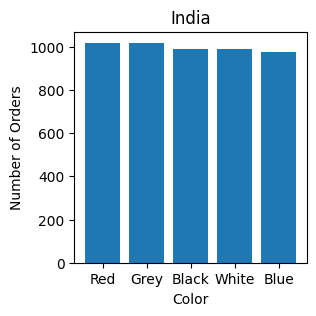

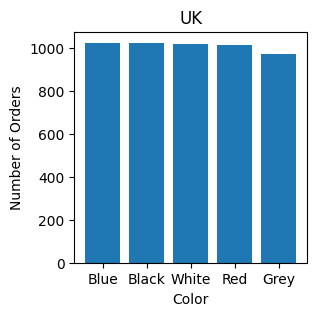

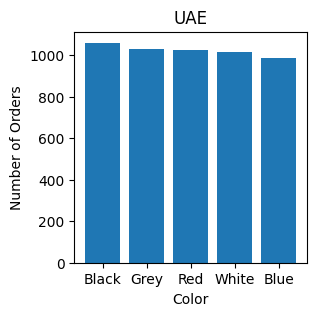

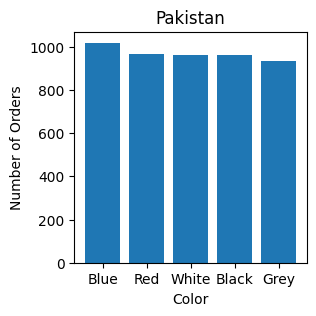

In [10]:
# Which color footwear/shoes most ordered by each country?

unique_color = df['color'].unique

for i in country:
  color = df[df['country'] == i].groupby('color')['order_id'].count().sort_values(ascending=False)
  plt.figure(figsize=(3,3))
  plt.bar(color.index,color.values)
  plt.title(i)
  plt.xlabel('Color')
  plt.ylabel('Number of Orders')
  plt.show()
#


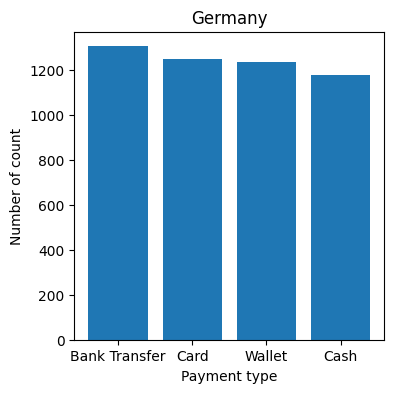

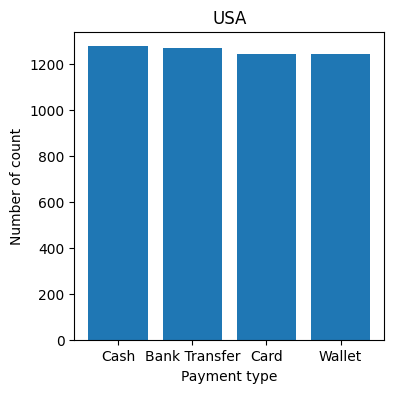

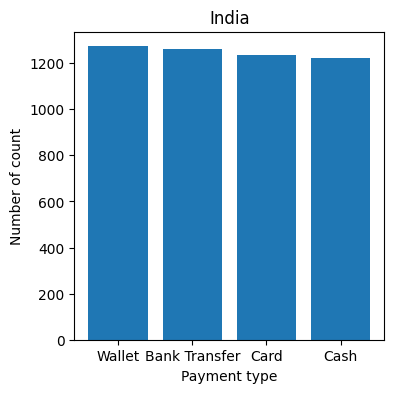

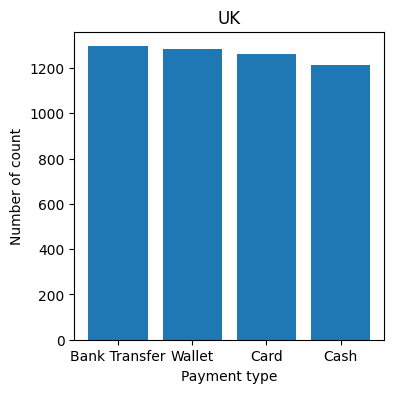

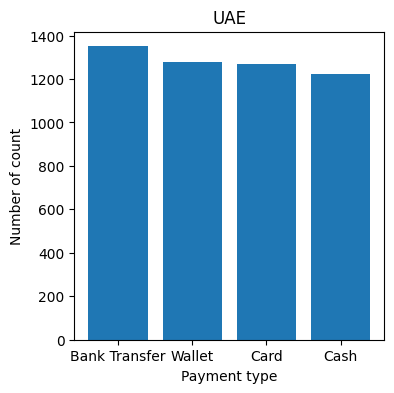

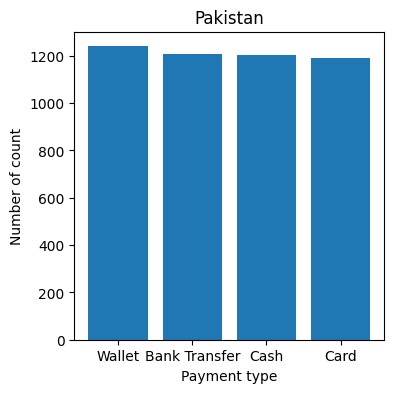

In [17]:
# Which type of payment method most used by each country?

for i in country:
  payment_by_country = df[df['country'] == i].groupby('payment_method')['order_id'].count().sort_values(ascending=False)
  plt.figure(figsize=(4,4))
  plt.bar(payment_by_country.index,payment_by_country.values)
  plt.xlabel('Payment type')
  plt.ylabel('Number of count')
  #plt.xticks(rotation=60)
  plt.title(i)
  plt.show()

In [24]:
# What is the average ratings given by each country?

for i in country:
  rating = df[df['country'] == i]['customer_rating'].mean()
  print(f'\n {i}: {round(rating)}')
#




 Germany: 4

 USA: 4

 India: 4

 UK: 4

 UAE: 4

 Pakistan: 4


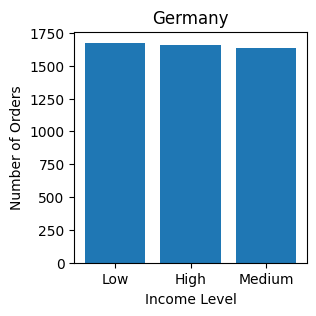

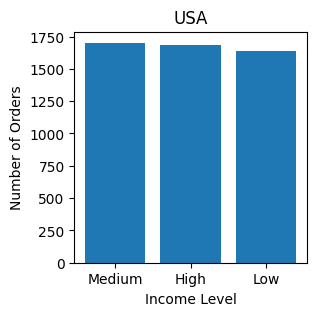

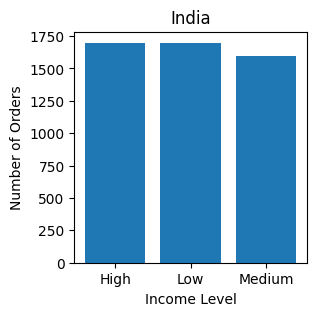

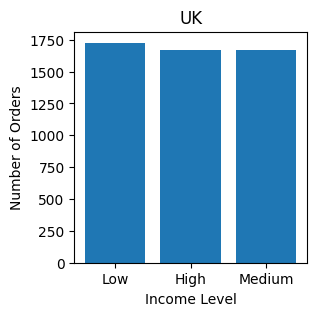

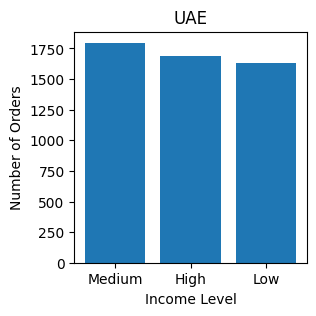

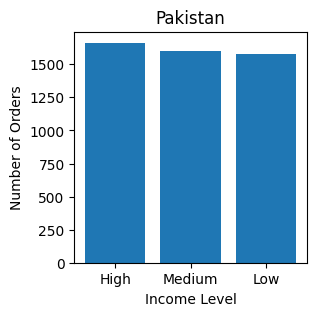

In [26]:
# Which type of income level customers are most ordered the footwears by each country?

for i in country:
  income_level = df[df['country'] == i].groupby('customer_income_level')['order_id'].count().sort_values(ascending=False)
  plt.figure(figsize=(3,3))
  plt.bar(income_level.index,income_level.values)
  plt.title(i)
  plt.xlabel('Income Level')
  plt.ylabel('Number of Orders')
  plt.show()
